In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


file_path = "../data/sales_data_sample.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")


print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (2823, 25)
Sütun Adları: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


In [3]:

display(df.head())


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [5]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

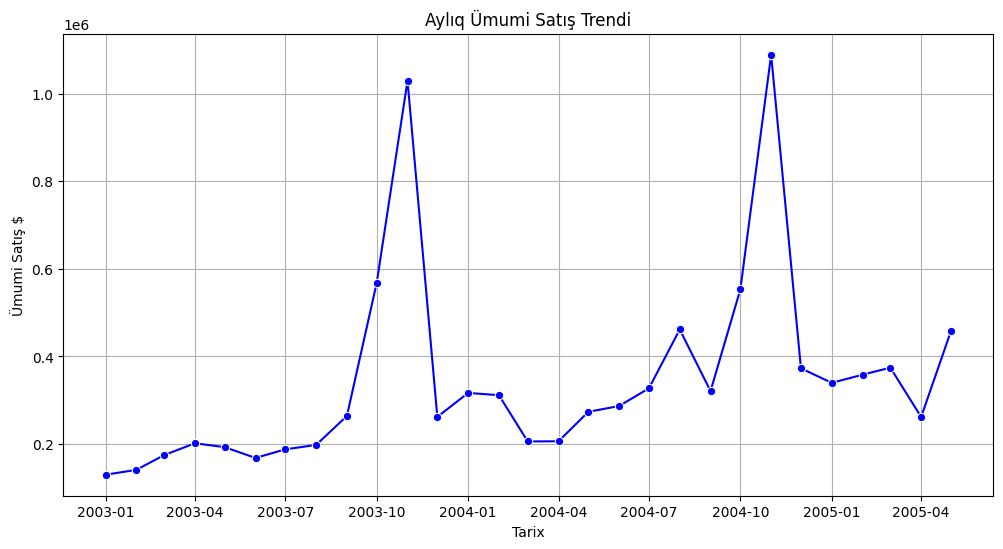

In [6]:
monthly_sales = df.groupby(df['ORDERDATE'].dt.to_period('M'))['SALES'].sum().reset_index()
monthly_sales['ORDERDATE'] = monthly_sales['ORDERDATE'].dt.to_timestamp()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='ORDERDATE', y='SALES', marker='o', color='b')
plt.title('Aylıq Ümumi Satış Trendi')
plt.xlabel('Tarix')
plt.ylabel('Ümumi Satış $')
plt.grid(True)
plt.show()

In [7]:
#  Hansı sütunda nə qədər boşluq var faizlə baxaq
missing_percentage = df.isnull().mean() * 100
print(missing_percentage[missing_percentage > 0])

ADDRESSLINE2    89.302161
STATE           52.639036
POSTALCODE       2.692171
TERRITORY       38.044633
dtype: float64


In [8]:
df_cleaned = df.copy()
df_cleaned['ADDRESSLINE2'] = df_cleaned['ADDRESSLINE2'].fillna('Unknown')
df_cleaned['STATE'] = df_cleaned['STATE'].fillna('Unknown')
df_cleaned['TERRITORY'] = df_cleaned['TERRITORY'].fillna('Unknown')
df_cleaned['POSTALCODE'] = df_cleaned['POSTALCODE'].fillna('Unknown')
print(df_cleaned.isnull().sum())

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64


In [9]:
df_cleaned.shape

(2823, 25)

C:\Users\Amin Rzazade\AppData\Local\Temp\ipykernel_25296\2690858047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales, x='SALES', y='PRODUCTLINE', palette='viridis')


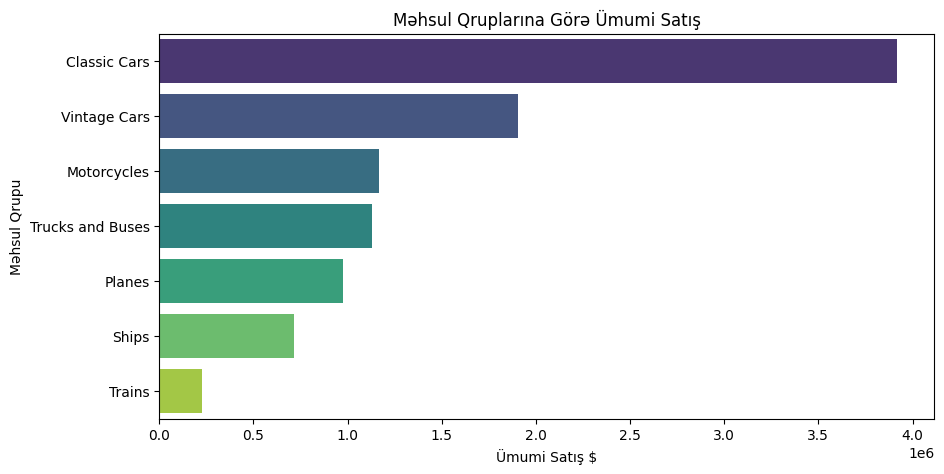

        PRODUCTLINE       SALES
0      Classic Cars  3919615.66
1      Vintage Cars  1903150.84
2       Motorcycles  1166388.34
3  Trucks and Buses  1127789.84
4            Planes   975003.57
5             Ships   714437.13
6            Trains   226243.47


In [10]:

product_sales = df_cleaned.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False).reset_index()


plt.figure(figsize=(10, 5))
sns.barplot(data=product_sales, x='SALES', y='PRODUCTLINE', palette='viridis')
plt.title('Məhsul Qruplarına Görə Ümumi Satış')
plt.xlabel('Ümumi Satış $')
plt.ylabel('Məhsul Qrupu')
plt.show()


print(product_sales)

In [11]:
duplicates = df_cleaned.duplicated().sum()
print(f"Dublikat sətirlərin  sayı: {duplicates}\n")

Dublikat sətirlərin  sayı: 0



In [12]:
display(df_cleaned.describe())

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2004-05-11 00:16:49.989373,2.717676,7.092455,2003.81509,100.715551
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2003-01-06 00:00:00,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2003-11-06 12:00:00,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,2004-06-15 00:00:00,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,2004-11-17 12:00:00,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,2005-05-31 00:00:00,4.000000,12.000000,2005.00000,214.000000
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,1.203878,3.656633,0.69967,40.187912


In [13]:
print(df_cleaned['STATUS'].value_counts())

STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64


In [15]:
print(df_cleaned['YEAR_ID'].value_counts())

YEAR_ID
2004    1345
2003    1000
2005     478
Name: count, dtype: int64


In [16]:
print(df_cleaned['PRODUCTLINE'].value_counts())

PRODUCTLINE
Classic Cars        967
Vintage Cars        607
Motorcycles         331
Planes              306
Trucks and Buses    301
Ships               234
Trains               77
Name: count, dtype: int64


C:\Users\Amin Rzazade\AppData\Local\Temp\ipykernel_25296\4203091738.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='YEAR_ID', ax=axes[1], palette='muted')
C:\Users\Amin Rzazade\AppData\Local\Temp\ipykernel_25296\4203091738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='count', y='COUNTRY', ax=axes[2], palette='coolwarm')


Text(0, 0.5, 'Ölkə')

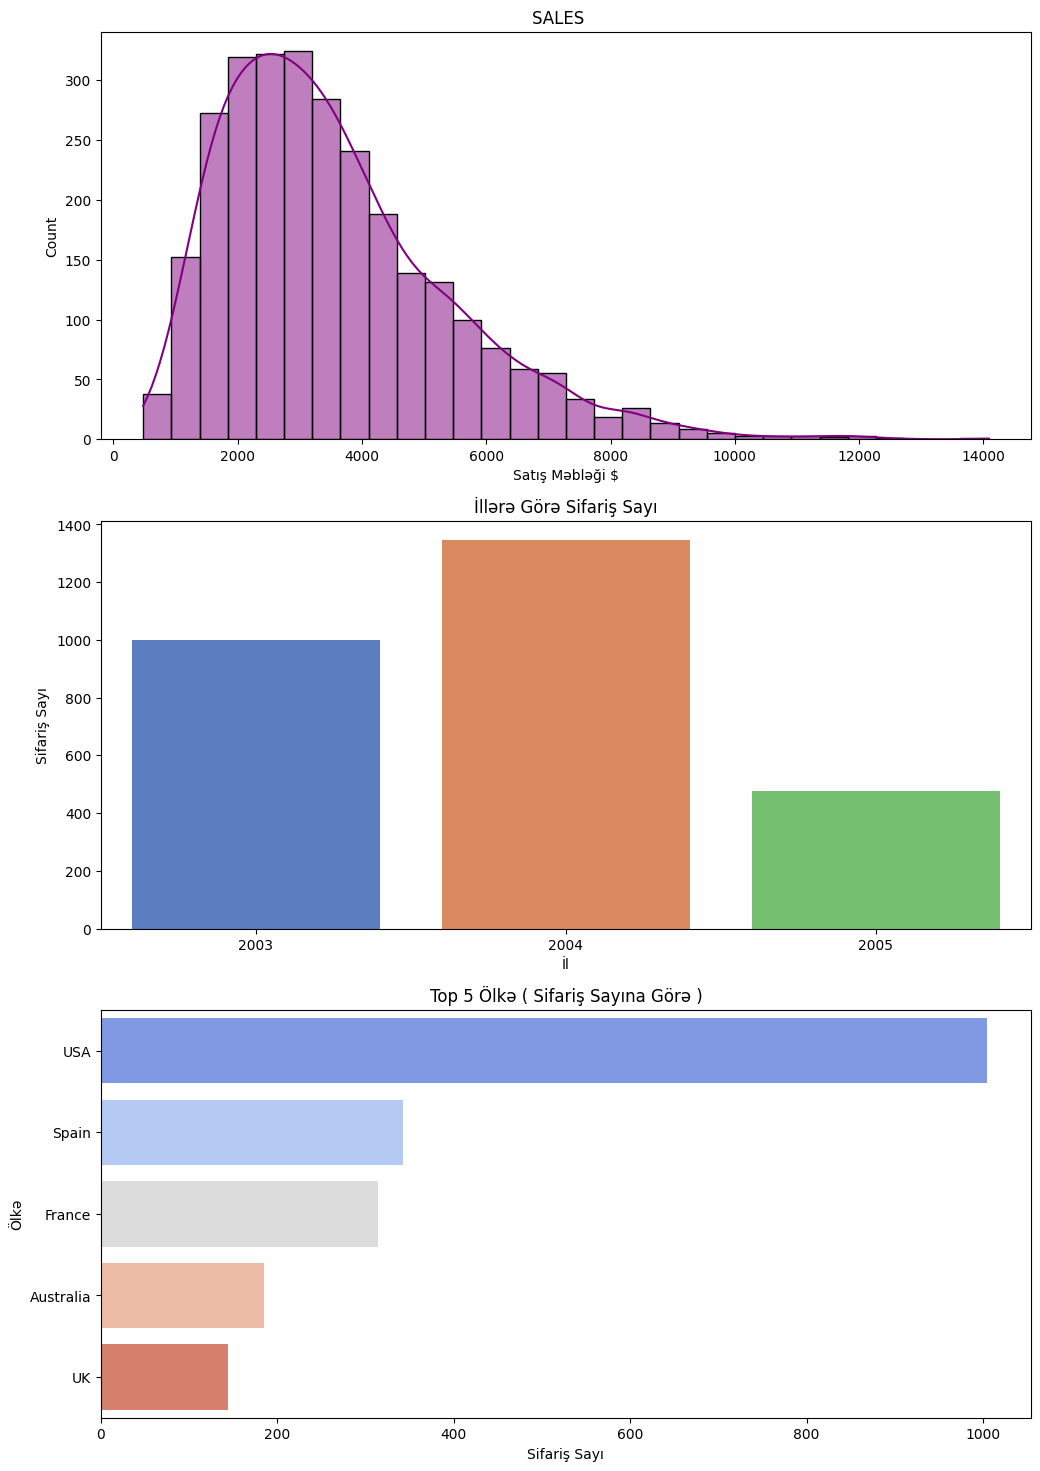

In [17]:
ig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.histplot(df_cleaned['SALES'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('SALES   ')
axes[0].set_xlabel('Satış Məbləği $')

sns.countplot(data=df_cleaned, x='YEAR_ID', ax=axes[1], palette='muted')
axes[1].set_title('İllərə Görə Sifariş Sayı')
axes[1].set_xlabel('İl')
axes[1].set_ylabel('Sifariş Sayı')


top_countries = df_cleaned['COUNTRY'].value_counts().head(5).reset_index()
sns.barplot(data=top_countries, x='count', y='COUNTRY', ax=axes[2], palette='coolwarm')
axes[2].set_title('Top 5 Ölkə ( Sifariş Sayına Görə )')
axes[2].set_xlabel('Sifariş Sayı')
axes[2].set_ylabel('Ölkə')

In [18]:
df_cleaned.to_csv("../data/sales_data_cleaned.csv", index=False)